# Is the market's probability any good?

A prediction market quotes a probability, so it can be scored the way any
forecast is scored. This recipe builds a reliability curve, decomposes the
Brier score into reliability, resolution and uncertainty, and reads off the
direction of the miscalibration. The methodological work is keeping the answer
key away from the forecast: resolutions live in their own table, they are dated
by the instant the result became *observable*, and a point-in-time read proves
the forecast could not have seen them.

## Terms used here

| term                                   | meaning |
| -------------------------------------- | --- |
| calibration                            | whether quoted probabilities match observed frequencies |
| reliability curve                      | observed frequency against quoted probability; the diagonal is perfect |
| Brier score                            | mean squared error of a probability forecast, so lower is better |
| reliability / resolution / uncertainty | the three parts the Brier score decomposes into |
| log loss                               | an alternative score that punishes confident errors far more harshly |
| base rate                              | how often the event happens overall, the benchmark any forecast must beat |
| observability                          | when the outcome became knowable, which is what the resolutions table is dated by |
| point-in-time                          | a read proving the forecast could not have seen the answer key |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cookbook_utils as cu
import h5i_db

db = h5i_db.Database(cu.fresh_db("05_probability_calibration"), create=True)

## The panel and the answer key

240 binary markets, each quoted through a session and then resolved. Two tables
matter here and they must not be confused.

`book_deltas` carries the forecast: the YES mid at any instant is the market's
probability. `resolutions` carries the outcome, one row per market.

| column | type | meaning |
|---|---|---|
| `ts_init` | `timestamp[ns]` | when the result became **observable**, not when the event occurred |
| `instrument_id` | `string` | the market |
| `kind` | `string` | `winner`, `split` or `void`; these fixtures are all winners |
| `outcome` | `uint16` | the winning outcome: 0 = YES won, 1 = NO won |

The distinction in that first row is the whole discipline. An election is
decided on election night but called hours later; settling against the earlier
instant books a profit nobody could have collected.

In [2]:
panel = cu.make_prediction_markets(n_markets=240, steps=48, seed=11)
for name, table in panel.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="panel load")
db.snapshot("panel-v1", tables=list(panel), note="calibration study input")
resolutions = panel["resolutions"]
print(f"resolutions: {resolutions.num_rows:,} rows x {resolutions.num_columns} columns")
resolutions.to_pandas().head()

resolutions: 240 rows x 6 columns


,ts_init,instrument_id,kind,outcome,payout,outcome_count
0,2026-05-02 00:30:00,EVENT-0000,winner,1,NaN,NaN
1,2026-05-02 00:30:00,EVENT-0001,winner,1,NaN,NaN
2,2026-05-02 00:30:00,EVENT-0002,winner,1,NaN,NaN
3,2026-05-02 00:30:00,EVENT-0003,winner,1,NaN,NaN
4,2026-05-02 00:30:00,EVENT-0004,winner,1,NaN,NaN


## The forecast, fixed at a decision time

Scoring needs one forecast per market, so pick a decision instant and read the
YES mid there. Everything after that instant is out of bounds for the forecast
and in bounds for the scoring.

In [3]:
stamps = sorted({value.as_py() for value in panel["book_deltas"].column("ts_init")})
decision = stamps[len(stamps) // 2]
decision_ns = int(pd.Timestamp(decision, tz="UTC").value)
print(f"session runs {stamps[0]} .. {stamps[-1]}")
print(f"decision instant: {decision} ({decision_ns} ns)")

forecasts = db.sql(
    f"""
    SELECT instrument_id,
           (max(CASE WHEN side = 'buy' THEN price END)
          + max(CASE WHEN side = 'sell' THEN price END)) / 2 AS p_yes
    FROM h5i('book_deltas', 'panel-v1')
    WHERE outcome = 0 AND ts_init = to_timestamp_nanos({decision_ns})
    GROUP BY instrument_id
    ORDER BY instrument_id
    """
).to_pandas()
print(f"\n{len(forecasts)} forecasts")
print(f"quoted probability spans {forecasts.p_yes.min():.3f} .. {forecasts.p_yes.max():.3f}")

session runs 2026-05-01 12:00:00 .. 2026-05-02 01:15:00
decision instant: 2026-05-01 18:30:00 (1777660200000000000 ns)

240 forecasts
quoted probability spans 0.093 .. 0.906


## Proof the forecast could not peek

`resolutions` is time-indexed on the observability instant, so a read bounded
at the decision time returns nothing. This is not a convention the analyst
remembers to honour; it is a property of the read. `time_end` is in the time
column's raw units, which is nanoseconds for these tables.

In [4]:
knowable = db.read("resolutions", time_end=decision_ns)
print(f"resolutions knowable at the decision instant: {knowable.num_rows}")
print(f"resolutions available now:                    {db.read('resolutions').num_rows}")
assert knowable.num_rows == 0

resolutions knowable at the decision instant: 0
resolutions available now:                    240


## Join the answer key, once

Now the labels are allowed in. `yes_won` is the realized outcome as a 0/1
variable, which is what every scoring rule below consumes.

In [5]:
truth = cu.market_truth(panel).to_pandas()
scored = forecasts.merge(truth, on="instrument_id", validate="one_to_one")
scored["y"] = scored.yes_won.astype(float)
print(f"{len(scored)} scored markets, base rate {scored.y.mean():.3f}")
scored.head()

240 scored markets, base rate 0.500


,instrument_id,p_yes,yes_won,y
0,EVENT-0000,0.114,False,0.0
1,EVENT-0001,0.096,False,0.0
2,EVENT-0002,0.105,False,0.0
3,EVENT-0003,0.093,False,0.0
4,EVENT-0004,0.102,False,0.0


## The reliability curve

Bucket by quoted probability and compare the mean quote with the realized
frequency. A calibrated market sits on the diagonal. The gap is signed: below
the diagonal means the bucket was overpriced.

In [6]:
EDGES = [0.0, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 0.90, 1.0]
scored["bucket"] = pd.cut(scored.p_yes, EDGES)
reliability = (
    scored.groupby("bucket", observed=True)
    .agg(n=("y", "size"), mean_quote=("p_yes", "mean"), realized=("y", "mean"))
    .assign(gap_pp=lambda f: (f.realized - f.mean_quote) * 100)
)
print(reliability.round(3).to_string())

              n  mean_quote  realized  gap_pp
bucket                                       
(0.0, 0.1]    2       0.094     0.000  -9.450
(0.1, 0.2]   30       0.153     0.067  -8.633
(0.2, 0.35]  44       0.278     0.250  -2.825
(0.35, 0.5]  44       0.424     0.409  -1.459
(0.5, 0.65]  45       0.574     0.622   4.787
(0.65, 0.8]  43       0.729     0.721  -0.793
(0.8, 0.9]   29       0.846     0.931   8.497
(0.9, 1.0]    3       0.904     1.000   9.600


The cheap buckets come in below their quoted probability and the expensive ones
above it. That is the favorite-longshot bias: longshots are overpriced,
favorites underpriced. Recipe 05/03 turns it into a trade.

In [7]:
low = reliability.head(3)
high = reliability.tail(3)
print(f"three cheapest buckets, mean gap: {np.average(low.gap_pp, weights=low.n):+.2f} pp")
print(f"three richest  buckets, mean gap: {np.average(high.gap_pp, weights=high.n):+.2f} pp")

three cheapest buckets, mean gap: -5.29 pp
three richest  buckets, mean gap: +3.21 pp


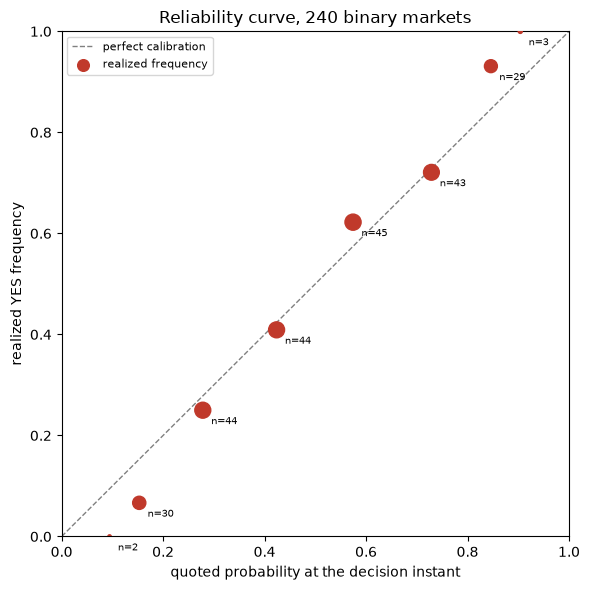

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color="grey", lw=1, ls="--", label="perfect calibration")
ax.scatter(reliability.mean_quote, reliability.realized, s=reliability.n * 3,
           color="#c0392b", zorder=3, label="realized frequency")
for row in reliability.itertuples():
    ax.annotate(f"n={row.n}", (row.mean_quote, row.realized),
                textcoords="offset points", xytext=(6, -10), fontsize=7)
ax.set_title("Reliability curve, 240 binary markets")
ax.set_xlabel("quoted probability at the decision instant")
ax.set_ylabel("realized YES frequency")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()

## Scoring rules

The Brier score is the mean squared error of a probability forecast. Its
Murphy decomposition splits it into three parts that answer different
questions: reliability is how far the buckets sit off the diagonal, resolution
is how much the forecast separates outcomes at all, and uncertainty is the
irreducible variance of the base rate.

`Brier = reliability - resolution + uncertainty`, so lower reliability is good
and higher resolution is good. A forecast that always quotes the base rate has
perfect reliability and zero resolution: useless but honest.

In [9]:
def brier_decomposition(p: pd.Series, y: pd.Series, edges: list[float]) -> dict[str, float]:
    """Murphy's three-term decomposition of the Brier score."""
    frame = pd.DataFrame({"p": p, "y": y})
    frame["bin"] = pd.cut(frame.p, edges)
    n = len(frame)
    base = frame.y.mean()
    groups = frame.groupby("bin", observed=True)
    counts = groups.size()
    reliability = float((counts * (groups.p.mean() - groups.y.mean()) ** 2).sum() / n)
    resolution = float((counts * (groups.y.mean() - base) ** 2).sum() / n)
    uncertainty = float(base * (1.0 - base))
    return {
        "brier": float(((frame.p - frame.y) ** 2).mean()),
        "reliability": reliability,
        "resolution": resolution,
        "uncertainty": uncertainty,
        "identity": reliability - resolution + uncertainty,
    }


def log_loss(p: pd.Series, y: pd.Series, floor: float = 1e-6) -> float:
    clipped = p.clip(floor, 1 - floor)
    return float(-(y * np.log(clipped) + (1 - y) * np.log(1 - clipped)).mean())


parts = brier_decomposition(scored.p_yes, scored.y, EDGES)
for key, value in parts.items():
    print(f"  {key:12} {value:.4f}")
print(f"  {'log loss':12} {log_loss(scored.p_yes, scored.y):.4f}")
assert abs(parts["brier"] - parts["identity"]) < 0.02

  brier        0.1772
  reliability  0.0026
  resolution   0.0756
  uncertainty  0.2500
  identity     0.1770
  log loss     0.5304


## Benchmarks, because a score alone means nothing

0.18 is neither good nor bad until it is compared. Two reference forecasts
bracket it: the base rate carries no information, and a recalibrated version of
the market price shows how much of the loss was miscalibration rather than
genuine uncertainty.

The recalibration inverts the compression this panel was built with. On real
data you would fit it out of sample; here the closed form makes the accounting
exact.

In [10]:
BIAS = 0.12
scored["p_recal"] = (0.5 + (scored.p_yes - 0.5) / (1.0 - BIAS)).clip(0.01, 0.99)
rows = []
for label, forecast in (
    ("market quote", scored.p_yes),
    ("base rate", pd.Series(scored.y.mean(), index=scored.index)),
    ("recalibrated", scored.p_recal),
):
    part = brier_decomposition(forecast, scored.y, EDGES)
    rows.append(
        {
            "forecast": label,
            "brier": part["brier"],
            "reliability": part["reliability"],
            "resolution": part["resolution"],
            "log_loss": log_loss(forecast, scored.y),
        }
    )
print(pd.DataFrame(rows).set_index("forecast").round(4).to_string())

               brier  reliability  resolution  log_loss
forecast                                               
market quote  0.1772       0.0026      0.0756    0.5304
base rate     0.2500       0.0000      0.0000    0.6931
recalibrated  0.1758       0.0006      0.0724    0.5234


The base rate has zero reliability error and zero resolution: it never
distinguishes one market from another. The market quote earns real resolution
and carries a reliability penalty, and recalibration cuts that penalty by
roughly four while keeping the resolution. That is the signature of a forecast
that ranks well but is scaled wrong.

Note how small the reliability term is in absolute terms. Bucket gaps of five to
nine points square down to a couple of thousandths, so a badly calibrated market
barely moves its own Brier score. The *sign structure* of the reliability curve
is the tradeable finding, not the magnitude of this term.

## Calibration does not improve through the session

Worth checking rather than assuming. Scoring the same markets at several
instants shows whether the market learns as expiry approaches. In this panel it
does not, because the mispricing was built to be persistent. On real data a
rising resolution term is what you would hope to see.

In [11]:
horizon = []
for index in (4, 16, 28, 40):
    at = stamps[index]
    at_ns = int(pd.Timestamp(at, tz="UTC").value)
    frame = db.sql(
        f"""
        SELECT instrument_id,
               (max(CASE WHEN side = 'buy' THEN price END)
              + max(CASE WHEN side = 'sell' THEN price END)) / 2 AS p_yes
        FROM h5i('book_deltas', 'panel-v1')
        WHERE outcome = 0 AND ts_init = to_timestamp_nanos({at_ns})
        GROUP BY instrument_id
        """
    ).to_pandas().merge(truth, on="instrument_id")
    frame["y"] = frame.yes_won.astype(float)
    part = brier_decomposition(frame.p_yes, frame.y, EDGES)
    horizon.append(
        {
            "instant": str(at.time()),
            "steps_to_expiry": len(stamps) - 1 - index,
            "brier": part["brier"],
            "reliability": part["reliability"],
            "resolution": part["resolution"],
        }
    )
print(pd.DataFrame(horizon).set_index("instant").round(4).to_string())

          steps_to_expiry   brier  reliability  resolution
instant                                                   
13:00:00               47  0.1776       0.0018      0.0722
16:00:00               35  0.1776       0.0020      0.0752
19:00:00               23  0.1774       0.0026      0.0722
22:00:00               11  0.1776       0.0022      0.0707


## Takeaways

- A quoted probability is a forecast and should be scored like one. The Brier
  decomposition says *why* a score is what it is: sitting off the diagonal
  (reliability) is a different failure from not separating outcomes at all
  (resolution).
- Score against benchmarks. The base rate bounds the useless end; a
  recalibrated forecast shows how much of the loss was scaling rather than
  ignorance.
- `resolutions` is dated by the instant the result became observable, not by
  the event. That is the column settlement is gated on in recipe 05/05.
- h5i-db features doing the work: the labels live in their own time-indexed
  table, so `db.read(..., time_end=decision_ns)` returning zero rows is a
  structural proof of no look-ahead, not a promise. The named snapshot makes
  every number above re-derivable from one pin.

In [12]:
db.close()